In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

1. Сколько студентов успешно сдали только один курс? (Успешная сдача — это зачёт по курсу на экзамене) (7 баллов).

2. Выяви самый сложный и самый простой экзамен: найди курсы и экзамены в рамках курса, которые обладают самой низкой и самой высокой завершаемостью*. (10 баллов)

3. По каждому предмету определи средний срок сдачи экзаменов (под сдачей понимаем последнее успешное прохождение экзамена студентом). (7 баллов) 

4. Выяви самые популярные предметы (ТОП-3) по количеству регистраций на них. А также предметы с самым большим оттоком (ТОП-3). (8 баллов)

5. Используя pandas, в период с начала 2013 по конец 2014 выяви семестр с самой низкой завершаемостью курсов и самыми долгими средними сроками сдачи курсов.  (15 баллов) 

6. Часто для качественного анализа аудитории использую подходы, основанные на сегментации. Используя python, построй адаптированные RFM-кластеры студентов, чтобы качественно оценить свою аудиторию. В адаптированной кластеризации можешь выбрать следующие метрики: R - среднее время сдачи одного экзамена, F - завершаемость курсов, M - среднее количество баллов, получаемое за экзамен. Подробно опиши, как ты создавал кластеры. Для каждого RFM-сегмента построй границы метрик recency, frequency и monetary для интерпретации этих кластеров. Описание подхода можно найти тут. (23 балла)

Для решения задачи проведи предварительное исследование данных и сформулируй, что должно считаться курсом. Обосновать свой выбор ты можешь с помощью фактов сдачи экзаменов, распределения студентов и уникальный идентефикатор курса.

*завершаемость = кол-во успешных экзаменов / кол-во всех попыток сдать экзамен

In [2]:
assessments = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//projects//2//assessments.csv')
assessments

,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0
...,...,...,...,...,...,...
201,GGG,2014J,37443,CMA,229.0,0.0
202,GGG,2014J,37435,TMA,61.0,0.0
203,GGG,2014J,37436,TMA,124.0,0.0
204,GGG,2014J,37437,TMA,173.0,0.0


assessments.csv — этот файл содержит информацию об оценках в тесте. Обычно каждый предмет в семестре включает ряд тестов с оценками, за которыми следует заключительный экзаменационный тест (экзамен).
code_module — идентификационный код предмета.

code_presentation — семестр (Идентификационный код).

id_assessment — тест (Идентификационный номер ассессмента).

assessment_type — тип теста. Существуют три типа оценивания: оценка преподавателя (TMA), компьютерная оценка (СМА), экзамен по курсу (Exam).

date — информация об окончательной дате сдачи теста. Рассчитывается как количество дней с момента начала семестра. Дата начала семестра имеет номер 0 (ноль).

weight — вес теста в % в оценке за курс. Обычно экзамены рассматриваются отдельно и имеют вес 100%; сумма всех остальных оценок составляет 100%.

In [3]:
courses = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//projects//2//courses.csv')
courses

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240
5,BBB,2014B,234
6,CCC,2014J,269
7,CCC,2014B,241
8,DDD,2013J,261
9,DDD,2014J,262


courses.csv — файл содержит список предметов по семестрам.
code_module — предмет (идентификационный код).

code_presentation — семестр (идентификационный код).

module_presentation_length — продолжительность семестра в днях.

In [4]:
studentAssessment = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//projects//2/studentAssessment.csv')
studentAssessment

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0
...,...,...,...,...,...
173907,37443,527538,227,0,60.0
173908,37443,534672,229,0,100.0
173909,37443,546286,215,0,80.0
173910,37443,546724,230,0,100.0


studentAssessment.csv — этот файл содержит результаты тестов студентов. Если учащийся не отправляет работу на оценку, результат не записывается в таблицу.
id_assessment — тест (идентификационный номер).

id_student — идентификационный номер студента.

date_submitted — дата сдачи теста студентом, измеряемая как количество дней с начала семестра.

is_banked — факт перезачета теста с прошлого семестра (иногда курсы перезачитывают студентам, вернувшимся из академического отпуска).

score — оценка учащегося в этом тесте. Диапазон составляет от 0 до 100. Оценка ниже 40 неудачная/неуспешная сдача теста.

In [5]:
studentRegistration = pd.read_csv('C://Users//Admin//Desktop//Devs//anal//projects//2/studentRegistration.csv')
studentRegistration

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN
...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,NaN
32589,GGG,2014J,2645731,-23.0,NaN
32590,GGG,2014J,2648187,-129.0,NaN
32591,GGG,2014J,2679821,-49.0,101.0


studentRegistration.csv — этот файл содержит информацию о времени, когда студент зарегистрировался для прохождения курса в семестре.
code_module — предмет (идентификационный код).

code_presentation — семестр (идентификационный код)

id_student — идентификационный номер студента.

date_registration — дата регистрации студента. Это количество дней, измеренное от начала семестра (например, отрицательное значение -30 означает, что студент зарегистрировался на прохождение курса за 30 дней до его начала).

date_unregistration — дата отмены регистрации студента с предмета. У студентов, окончивших курс, это поле остается пустым.

In [6]:
assessments.query("assessment_type == 'Exam'")

,code_module,code_presentation,id_assessment,assessment_type,date,weight
5,AAA,2013J,1757,Exam,NaN,100.0
11,AAA,2014J,1763,Exam,NaN,100.0
23,BBB,2013B,14990,Exam,NaN,100.0
35,BBB,2013J,15002,Exam,NaN,100.0
47,BBB,2014B,15014,Exam,NaN,100.0
53,BBB,2014J,15025,Exam,NaN,100.0
62,CCC,2014B,24290,Exam,NaN,100.0
63,CCC,2014B,40087,Exam,NaN,100.0
72,CCC,2014J,24299,Exam,NaN,100.0
73,CCC,2014J,40088,Exam,NaN,100.0


In [7]:
assessments_studentAssessmen = assessments.merge(studentAssessment, on = 'id_assessment', how = 'outer')
assessments_studentAssessmen

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
0,AAA,2013J,1752,TMA,19.0,10.0,11391.0,18.0,0.0,78.0
1,AAA,2013J,1752,TMA,19.0,10.0,28400.0,22.0,0.0,70.0
2,AAA,2013J,1752,TMA,19.0,10.0,31604.0,17.0,0.0,72.0
3,AAA,2013J,1752,TMA,19.0,10.0,32885.0,26.0,0.0,69.0
4,AAA,2013J,1752,TMA,19.0,10.0,38053.0,19.0,0.0,79.0
...,...,...,...,...,...,...,...,...,...,...
173925,GGG,2014J,37437,TMA,173.0,0.0,652539.0,176.0,0.0,75.0
173926,GGG,2014J,37437,TMA,173.0,0.0,653157.0,187.0,0.0,70.0
173927,GGG,2014J,37437,TMA,173.0,0.0,653252.0,171.0,0.0,70.0
173928,GGG,2014J,37437,TMA,173.0,0.0,653374.0,172.0,0.0,50.0


In [8]:
assessments_studentAssessmen = assessments_studentAssessmen.fillna(0)

In [9]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0")\
    .groupby(['code_module', 'code_presentation', 'id_assessment'])\
    .agg({'is_banked': 'count'})

is_banked
code_module code_presentation id_assessment           
CCC         2014B             24290                747
            2014J             24299               1168
DDD         2013B             25340                602
            2013J             25354                968
            2014B             25361                524
            2014J             25368                950

In [10]:
assessments_studentAssessmen.query("is_banked !=0 & assessment_type == 'Exam' & id_student !=0")

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score


In [11]:
assessments_studentAssessmen.query("score>0 & assessment_type == 'Exam'").score.describe()

count    4956.000000
mean       65.612591
std        20.522047
min         4.000000
25%        51.000000
50%        67.000000
75%        82.000000
max       100.000000
Name: score, dtype: float64

In [12]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
52930,CCC,2014B,24290,Exam,0.0,100.0,559706.0,234.0,0.0,78.0
52931,CCC,2014B,24290,Exam,0.0,100.0,559770.0,230.0,0.0,54.0
52932,CCC,2014B,24290,Exam,0.0,100.0,560114.0,230.0,0.0,64.0
52933,CCC,2014B,24290,Exam,0.0,100.0,560311.0,234.0,0.0,100.0
52934,CCC,2014B,24290,Exam,0.0,100.0,560494.0,230.0,0.0,92.0
...,...,...,...,...,...,...,...,...,...,...
95986,DDD,2014J,25368,Exam,0.0,100.0,652617.0,243.0,0.0,56.0
95988,DDD,2014J,25368,Exam,0.0,100.0,652680.0,243.0,0.0,91.0
95989,DDD,2014J,25368,Exam,0.0,100.0,652732.0,249.0,0.0,47.0
95990,DDD,2014J,25368,Exam,0.0,100.0,652965.0,242.0,0.0,87.0


In [13]:
students_double_list = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")\
    .groupby('id_student',as_index = False)\
    .agg({'is_banked': 'count'})\
    .query("is_banked>1")\
    .id_student.tolist()

In [14]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40 & id_student in @students_double_list")

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
52930,CCC,2014B,24290,Exam,0.0,100.0,559706.0,234.0,0.0,78.0
52932,CCC,2014B,24290,Exam,0.0,100.0,560114.0,230.0,0.0,64.0
52933,CCC,2014B,24290,Exam,0.0,100.0,560311.0,234.0,0.0,100.0
52941,CCC,2014B,24290,Exam,0.0,100.0,563819.0,230.0,0.0,74.0
52953,CCC,2014B,24290,Exam,0.0,100.0,570872.0,236.0,0.0,42.0
...,...,...,...,...,...,...,...,...,...,...
95918,DDD,2014J,25368,Exam,0.0,100.0,647464.0,242.0,0.0,76.0
95932,DDD,2014J,25368,Exam,0.0,100.0,648854.0,243.0,0.0,64.0
95971,DDD,2014J,25368,Exam,0.0,100.0,651495.0,245.0,0.0,91.0
95973,DDD,2014J,25368,Exam,0.0,100.0,651508.0,242.0,0.0,82.0


In [15]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40 & id_student in @students_double_list")\
    .groupby(['id_student', 'code_module'], as_index = False)\
    .agg({'is_banked': 'count'})\
    .sort_values('is_banked', ascending = False)

,id_student,code_module,is_banked
309,593903.0,DDD,2
360,605118.0,DDD,2
138,540758.0,DDD,2
0,80329.0,CCC,1
395,615075.0,CCC,1
...,...,...,...
197,567304.0,CCC,1
198,567304.0,DDD,1
199,568948.0,CCC,1
200,568948.0,DDD,1


In [16]:
4392-587 

3805

4392 студента сдали успешно ЭКЗАМЕН, 587 из них успешно сдали экзамен по разным (по двум) курсам, 3 сдали дважды успешно
по одному и тому же курсу. Ответ на вопрос Сколько студентов успешно сдали только один курс? (Успешная сдача — это зачёт по курсу на экзамене) 4392 - 590 = 3802, если считать повторное прохождение курса за 2 курса или 4392-587  = 3805, если считать повторное прохождение за один курс

In [17]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0")

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
52929,CCC,2014B,24290,Exam,0.0,100.0,558914.0,230.0,0.0,32.0
52930,CCC,2014B,24290,Exam,0.0,100.0,559706.0,234.0,0.0,78.0
52931,CCC,2014B,24290,Exam,0.0,100.0,559770.0,230.0,0.0,54.0
52932,CCC,2014B,24290,Exam,0.0,100.0,560114.0,230.0,0.0,64.0
52933,CCC,2014B,24290,Exam,0.0,100.0,560311.0,234.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...
95988,DDD,2014J,25368,Exam,0.0,100.0,652680.0,243.0,0.0,91.0
95989,DDD,2014J,25368,Exam,0.0,100.0,652732.0,249.0,0.0,47.0
95990,DDD,2014J,25368,Exam,0.0,100.0,652965.0,242.0,0.0,87.0
95991,DDD,2014J,25368,Exam,0.0,100.0,653051.0,242.0,0.0,27.0


In [18]:
total_exam = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0")\
    .groupby(['code_module', 'id_assessment'], as_index=False)\
    .agg({'score': 'count'})
total_exam

,code_module,id_assessment,score
0,CCC,24290,747
1,CCC,24299,1168
2,DDD,25340,602
3,DDD,25354,968
4,DDD,25361,524
5,DDD,25368,950


In [19]:
acsees_exam = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")\
    .groupby(['code_module', 'id_assessment'], as_index=False)\
    .agg({'score': 'count'})
acsees_exam

,code_module,id_assessment,score
0,CCC,24290,664
1,CCC,24299,1019
2,DDD,25340,504
3,DDD,25354,878
4,DDD,25361,485
5,DDD,25368,842


In [20]:
acsees_exam.score/total_exam.score

0    0.888889
1    0.872432
2    0.837209
3    0.907025
4    0.925573
5    0.886316
Name: score, dtype: float64

2. Выяви самый сложный и самый простой экзамен: найди курсы и экзамены в рамках курса, которые обладают самой низкой и самой высокой завершаемостью
Самый сложный экзамен - 25340  Курс DDD, самый простой - 25361 курс DDD

По каждому предмету определи средний срок сдачи экзаменов (под сдачей понимаем последнее успешное прохождение экзамена студентом)

In [21]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")\
    .groupby('code_module', as_index = False)\
    .agg({'date_submitted': 'mean'})\
    .round(0)
 

,code_module,date_submitted
0,CCC,239.0
1,DDD,238.0


Выяви самые популярные предметы (ТОП-3) по количеству регистраций на них. А также предметы с самым большим оттоком (ТОП-3). (8 баллов)

In [22]:
studentRegistration.head()

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,NaN
1,AAA,2013J,28400,-53.0,NaN
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,NaN
4,AAA,2013J,32885,-176.0,NaN


In [23]:
studentRegistration\
    .fillna(0)\
    .groupby('code_module', as_index=False)\
    .agg({'id_student': 'nunique'})\
    .sort_values('id_student', ascending=False)\
    .head(3)
    #топ 3 самых популрных курса по количеству регистраций

,code_module,id_student
1,BBB,7692
5,FFF,7397
3,DDD,5848


In [24]:
studentRegistration\
    .fillna(0)\
    .groupby(['code_module', 'id_student'], as_index=False)\
    .agg({'date_unregistration': 'nunique'})\
    .sort_values('date_unregistration')
 


,code_module,id_student,date_unregistration
0,AAA,6516,1
20712,EEE,654213,1
20711,EEE,654202,1
20710,EEE,654198,1
20709,EEE,654125,1
...,...,...,...
13272,DDD,309258,3
25236,FFF,592939,3
14867,DDD,544649,3
28518,FFF,2463282,3


In [25]:
def alert(row):
    if row['date_unregistration'] == 'Q':
        return 0
    else:
        return 1



In [26]:
studentRegistration = studentRegistration.fillna('Q')
studentRegistration

,code_module,code_presentation,id_student,date_registration,date_unregistration
0,AAA,2013J,11391,-159.0,Q
1,AAA,2013J,28400,-53.0,Q
2,AAA,2013J,30268,-92.0,12.0
3,AAA,2013J,31604,-52.0,Q
4,AAA,2013J,32885,-176.0,Q
...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,Q
32589,GGG,2014J,2645731,-23.0,Q
32590,GGG,2014J,2648187,-129.0,Q
32591,GGG,2014J,2679821,-49.0,101.0


In [27]:
studentRegistration['alert'] = studentRegistration.apply(alert, axis=1)
studentRegistration

,code_module,code_presentation,id_student,date_registration,date_unregistration,alert
0,AAA,2013J,11391,-159.0,Q,0
1,AAA,2013J,28400,-53.0,Q,0
2,AAA,2013J,30268,-92.0,12.0,1
3,AAA,2013J,31604,-52.0,Q,0
4,AAA,2013J,32885,-176.0,Q,0
...,...,...,...,...,...,...
32588,GGG,2014J,2640965,-4.0,Q,0
32589,GGG,2014J,2645731,-23.0,Q,0
32590,GGG,2014J,2648187,-129.0,Q,0
32591,GGG,2014J,2679821,-49.0,101.0,1


In [28]:
studentRegistration\
    .fillna(0)\
    .groupby(['code_module', 'id_student'], as_index=False)\
    .agg({'alert': 'min'})\
    .sort_values('alert')\
    .groupby('code_module', as_index=False)\
    .agg({'alert': 'mean'})\
    .sort_values('alert', ascending=False)\
    .head(3)
   #топ оттока студентов 
 


,code_module,alert
2,CCC,0.414961
3,DDD,0.314466
1,BBB,0.283411


Используя pandas, в период с начала 2013 по конец 2014 выяви семестр с самой низкой завершаемостью курсов и самыми долгими средними сроками сдачи курсов. (15 баллов)


In [29]:
assessments_studentAssessmen.head()

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
0,AAA,2013J,1752,TMA,19.0,10.0,11391.0,18.0,0.0,78.0
1,AAA,2013J,1752,TMA,19.0,10.0,28400.0,22.0,0.0,70.0
2,AAA,2013J,1752,TMA,19.0,10.0,31604.0,17.0,0.0,72.0
3,AAA,2013J,1752,TMA,19.0,10.0,32885.0,26.0,0.0,69.0
4,AAA,2013J,1752,TMA,19.0,10.0,38053.0,19.0,0.0,79.0


In [30]:
total_exam2 = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0")\
    .groupby(['code_module', 'code_presentation'], as_index=False)\
    .agg({'score': 'count'})
total_exam2

,code_module,code_presentation,score
0,CCC,2014B,747
1,CCC,2014J,1168
2,DDD,2013B,602
3,DDD,2013J,968
4,DDD,2014B,524
5,DDD,2014J,950


In [31]:
acsees_exam2 = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")\
    .groupby(['code_module', 'code_presentation'], as_index=False)\
    .agg({'score': 'count'})
acsees_exam2

,code_module,code_presentation,score
0,CCC,2014B,664
1,CCC,2014J,1019
2,DDD,2013B,504
3,DDD,2013J,878
4,DDD,2014B,485
5,DDD,2014J,842


In [32]:
acsees_exam2.score/total_exam2.score
# 2013B самая низкая завершаемость

0    0.888889
1    0.872432
2    0.837209
3    0.907025
4    0.925573
5    0.886316
Name: score, dtype: float64

In [33]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & score>=40")\
    .groupby('code_presentation', as_index=False)\
    .agg({'date_submitted': 'mean'})\
    .sort_values('date_submitted', ascending=False)
    

,code_presentation,date_submitted
3,2014J,243.680279
1,2013J,239.509112
2,2014B,232.997389
0,2013B,230.164683


Часто для качественного анализа аудитории использую подходы, основанные на сегментации. Используя python, построй адаптированные RFM-кластеры студентов, чтобы качественно оценить свою аудиторию. В адаптированной кластеризации можешь выбрать следующие метрики: R - среднее время сдачи одного экзамена, F - завершаемость курсов, M - среднее количество баллов, получаемое за экзамен. Подробно опиши, как ты создавал кластеры. Для каждого RFM-сегмента построй границы метрик recency, frequency и monetary для интерпретации этих кластеров. Описание подхода можно найти тут. (23 балла)

In [34]:
assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0").date_submitted.describe()

count    4959.000000
mean      238.483565
std         5.717577
min       229.000000
25%       234.000000
50%       241.000000
75%       243.000000
max       285.000000
Name: date_submitted, dtype: float64

In [35]:
df_rfm = assessments_studentAssessmen.query("assessment_type == 'Exam' & id_student !=0 & date_submitted>date")
df_rfm

,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score
52929,CCC,2014B,24290,Exam,0.0,100.0,558914.0,230.0,0.0,32.0
52930,CCC,2014B,24290,Exam,0.0,100.0,559706.0,234.0,0.0,78.0
52931,CCC,2014B,24290,Exam,0.0,100.0,559770.0,230.0,0.0,54.0
52932,CCC,2014B,24290,Exam,0.0,100.0,560114.0,230.0,0.0,64.0
52933,CCC,2014B,24290,Exam,0.0,100.0,560311.0,234.0,0.0,100.0
...,...,...,...,...,...,...,...,...,...,...
95988,DDD,2014J,25368,Exam,0.0,100.0,652680.0,243.0,0.0,91.0
95989,DDD,2014J,25368,Exam,0.0,100.0,652732.0,249.0,0.0,47.0
95990,DDD,2014J,25368,Exam,0.0,100.0,652965.0,242.0,0.0,87.0
95991,DDD,2014J,25368,Exam,0.0,100.0,653051.0,242.0,0.0,27.0


In [39]:
def acs(row):
    if row['score'] >= 40:
        return 1
    else:
        return 0

In [40]:
df_rfm['assessment'] = df_rfm.apply(acs, axis=1)
df_rfm

C:\Users\Admin\AppData\Local\Temp\ipykernel_11748\1532037181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rfm['assessment'] = df_rfm.apply(acs, axis=1)


,code_module,code_presentation,id_assessment,assessment_type,date,weight,id_student,date_submitted,is_banked,score,assessment
52929,CCC,2014B,24290,Exam,0.0,100.0,558914.0,230.0,0.0,32.0,0
52930,CCC,2014B,24290,Exam,0.0,100.0,559706.0,234.0,0.0,78.0,1
52931,CCC,2014B,24290,Exam,0.0,100.0,559770.0,230.0,0.0,54.0,1
52932,CCC,2014B,24290,Exam,0.0,100.0,560114.0,230.0,0.0,64.0,1
52933,CCC,2014B,24290,Exam,0.0,100.0,560311.0,234.0,0.0,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...
95988,DDD,2014J,25368,Exam,0.0,100.0,652680.0,243.0,0.0,91.0,1
95989,DDD,2014J,25368,Exam,0.0,100.0,652732.0,249.0,0.0,47.0,1
95990,DDD,2014J,25368,Exam,0.0,100.0,652965.0,242.0,0.0,87.0,1
95991,DDD,2014J,25368,Exam,0.0,100.0,653051.0,242.0,0.0,27.0,0


In [41]:
rfm = df_rfm.groupby(['id_student', 'date'], as_index=False)\
    .agg({'date_submitted':'mean', 'assessment': 'mean', 'score': 'mean'})\
    .rename(columns = {'date_submitted': 'recency', 'assessment': 'frequency', 'score': 'monetary'})
rfm

,id_student,date,recency,frequency,monetary
0,23698.0,0.0,243.0,1.0,80.0
1,27116.0,0.0,243.0,1.0,96.0
2,28787.0,0.0,243.0,1.0,44.0
3,29420.0,0.0,244.0,1.0,62.0
4,29639.0,0.0,248.0,1.0,74.0
...,...,...,...,...,...
2814,2689863.0,0.0,242.0,1.0,67.0
2815,2691267.0,0.0,244.0,1.0,82.0
2816,2691861.0,0.0,248.0,0.0,38.0
2817,2692327.0,0.0,234.0,1.0,88.0


In [42]:
rfm.frequency.unique()

array([1. , 0. , 0.5])

In [43]:
def r_score(row):
    if row['date'] == 0:
        return 3
    elif row['recency'] < row['date']:
        return 3
    elif row['recency'] == row['date']:
        return 2
    else:
        return 1
        

In [44]:
rfm['r'] = rfm.apply(r_score, axis=1)
rfm

,id_student,date,recency,frequency,monetary,r
0,23698.0,0.0,243.0,1.0,80.0,3
1,27116.0,0.0,243.0,1.0,96.0,3
2,28787.0,0.0,243.0,1.0,44.0,3
3,29420.0,0.0,244.0,1.0,62.0,3
4,29639.0,0.0,248.0,1.0,74.0,3
...,...,...,...,...,...,...
2814,2689863.0,0.0,242.0,1.0,67.0,3
2815,2691267.0,0.0,244.0,1.0,82.0,3
2816,2691861.0,0.0,248.0,0.0,38.0,3
2817,2692327.0,0.0,234.0,1.0,88.0,3


In [45]:
def f_score(row):
    if row['frequency'] == 1:
        return 3
    elif row['frequency'] == 0.5:
        return 2
    else:
        return 1
        

In [46]:
rfm['f'] = rfm.apply(f_score, axis=1)
rfm

,id_student,date,recency,frequency,monetary,r,f
0,23698.0,0.0,243.0,1.0,80.0,3,3
1,27116.0,0.0,243.0,1.0,96.0,3,3
2,28787.0,0.0,243.0,1.0,44.0,3,3
3,29420.0,0.0,244.0,1.0,62.0,3,3
4,29639.0,0.0,248.0,1.0,74.0,3,3
...,...,...,...,...,...,...,...
2814,2689863.0,0.0,242.0,1.0,67.0,3,3
2815,2691267.0,0.0,244.0,1.0,82.0,3,3
2816,2691861.0,0.0,248.0,0.0,38.0,3,1
2817,2692327.0,0.0,234.0,1.0,88.0,3,3


In [47]:
quant = pd.cut(rfm.monetary, 3, labels=[1, 2, 3])

In [48]:
rfm['m'] = pd.cut(rfm.monetary, 3, labels=[1, 2, 3])

In [49]:
rfm['m'] = rfm['m'].astype('int64')
rfm.dtypes

id_student    float64
date          float64
recency       float64
frequency     float64
monetary      float64
r               int64
f               int64
m               int64
dtype: object

In [50]:
rfm['rfm_score'] = rfm['r'].map(str) + rfm['f'].map(str) + rfm['m'].map(str)
rfm.head()

,id_student,date,recency,frequency,monetary,r,f,m,rfm_score
0,23698.0,0.0,243.0,1.0,80.0,3,3,3,333
1,27116.0,0.0,243.0,1.0,96.0,3,3,3,333
2,28787.0,0.0,243.0,1.0,44.0,3,3,2,332
3,29420.0,0.0,244.0,1.0,62.0,3,3,2,332
4,29639.0,0.0,248.0,1.0,74.0,3,3,3,333


In [51]:
rfm.rfm_score.unique()

array(['333', '332', '311', '111', '312', '133', '132', '322'],
      dtype=object)

In [52]:
def segment(row):
    if row['rfm_score'] == '333':
        return 'отличник'
    elif row['rfm_score'] == '332':
        return 'хорошист'
    elif row['rfm_score'] == '311':
        return 'не сдал'
    elif row['rfm_score'] == '111':
        return 'не сдал, опоздал'
    elif row['rfm_score'] == '312':
        return 'не сдал, чуть не дотянул'
    elif row['rfm_score'] == '133':
        return 'умный раздолбай'
    elif row['rfm_score'] == '132':
        return ' менее умный раздолбай'
    elif row['rfm_score'] == '322':
        return 'сдал, но не всё'
    
        

In [53]:
rfm['segment'] = rfm.apply(segment, axis=1)
rfm

,id_student,date,recency,frequency,monetary,r,f,m,rfm_score,segment
0,23698.0,0.0,243.0,1.0,80.0,3,3,3,333,отличник
1,27116.0,0.0,243.0,1.0,96.0,3,3,3,333,отличник
2,28787.0,0.0,243.0,1.0,44.0,3,3,2,332,хорошист
3,29420.0,0.0,244.0,1.0,62.0,3,3,2,332,хорошист
4,29639.0,0.0,248.0,1.0,74.0,3,3,3,333,отличник
...,...,...,...,...,...,...,...,...,...,...
2814,2689863.0,0.0,242.0,1.0,67.0,3,3,3,333,отличник
2815,2691267.0,0.0,244.0,1.0,82.0,3,3,3,333,отличник
2816,2691861.0,0.0,248.0,0.0,38.0,3,1,2,312,"не сдал, чуть не дотянул"
2817,2692327.0,0.0,234.0,1.0,88.0,3,3,3,333,отличник


In [54]:
cluster_map = rfm.groupby('segment', as_index=False)\
    .agg({'date': 'count'})\
    .rename(columns = {'date': 'stu_count'})
cluster_map

,segment,stu_count
0,менее умный раздолбай,3
1,не сдал,205
2,"не сдал, опоздал",1
3,"не сдал, чуть не дотянул",132
4,отличник,1462
5,"сдал, но не всё",3
6,умный раздолбай,3
7,хорошист,1010


In [55]:
cluster_map.stu_count.dtypes

dtype('int64')

In [56]:
cluster_map['per'] = cluster_map.stu_count/2819*100

In [57]:
cluster_map

,segment,stu_count,per
0,менее умный раздолбай,3,0.106421
1,не сдал,205,7.272082
2,"не сдал, опоздал",1,0.035474
3,"не сдал, чуть не дотянул",132,4.682512
4,отличник,1462,51.862363
5,"сдал, но не всё",3,0.106421
6,умный раздолбай,3,0.106421
7,хорошист,1010,35.828308


([<matplotlib.patches.Wedge at 0x24a09aeb010>,
 [Text(1.0999938522755546, 0.003677629125628816, ' менее умный раздолбай'),
  Text(1.0697284149555024, 0.25628327732567463, 'не сдал'),
  Text(0.9833420594116766, 0.49298924348509143, 'не сдал, опоздал'),
  Text(0.8997566895168617, 0.6328016274233639, 'не сдал, чуть не дотянул'),
  Text(-0.8031734534857602, 0.7516065484119717, 'отличник'),
  Text(-0.7005237471128728, -0.8480957963172203, 'сдал, но не всё'),
  Text(-0.6948372423851847, -0.8527609316769573, 'умный раздолбай'),
  Text(0.4737190959376165, -0.9927689651394463, 'хорошист')])

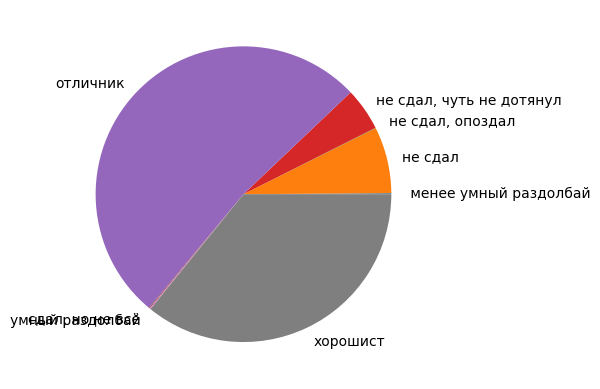

In [58]:
fig, ax = plt.subplots()
ax.pie(cluster_map.stu_count, labels=cluster_map.segment)

In [59]:
rfm

,id_student,date,recency,frequency,monetary,r,f,m,rfm_score,segment
0,23698.0,0.0,243.0,1.0,80.0,3,3,3,333,отличник
1,27116.0,0.0,243.0,1.0,96.0,3,3,3,333,отличник
2,28787.0,0.0,243.0,1.0,44.0,3,3,2,332,хорошист
3,29420.0,0.0,244.0,1.0,62.0,3,3,2,332,хорошист
4,29639.0,0.0,248.0,1.0,74.0,3,3,3,333,отличник
...,...,...,...,...,...,...,...,...,...,...
2814,2689863.0,0.0,242.0,1.0,67.0,3,3,3,333,отличник
2815,2691267.0,0.0,244.0,1.0,82.0,3,3,3,333,отличник
2816,2691861.0,0.0,248.0,0.0,38.0,3,1,2,312,"не сдал, чуть не дотянул"
2817,2692327.0,0.0,234.0,1.0,88.0,3,3,3,333,отличник


IndexError: Inconsistent shape between the condition and the input (got (2819, 1) and (2819,))

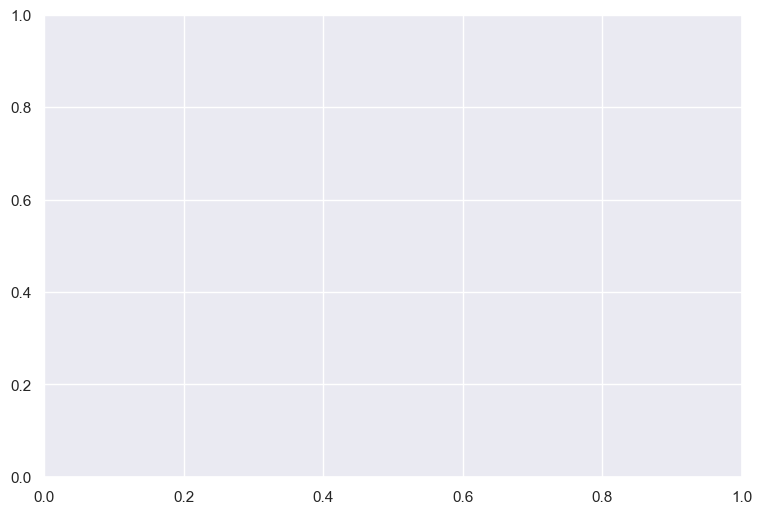

In [60]:
sns.set_theme()

# Load the example flights dataset and convert to long-form

# Draw a heatmap with the numeric values in each cell
f, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(rfm.rfm_score, annot=True, fmt="d", linewidths=.5, ax=ax)